# Import Modules & Config

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display
from pathlib import Path
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import root_mean_squared_error, mean_absolute_percentage_error
from sklearn import tree
from sklearn.ensemble._forest import _generate_sample_indices
from statsmodels.graphics.tsaplots import plot_pacf
from statsmodels.tsa.stattools import pacf

sugar_selector = widgets.Dropdown(
    options=['local', 'premium'],
    value='local',
    description='Sugar Type',
)

train_size_slider = widgets.FloatSlider(
    value=0.9,
    min=0.6,
    max=0.9,
    step=0.05,
    description='Train Size'
)

history_plot_checkbox = widgets.Checkbox(
  value=False,
  description='Generate History Plot'
)

pacf_plot_checkbox = widgets.Checkbox(
  value=False,
  description='Generate PACF Plot'
)

compare_prediction_checkbox = widgets.Checkbox(
  value=False,
  description='Generate Actual vs Prediction Plot'
)

forecast_checkbox = widgets.Checkbox(
  value=False,
  description='Forecast Sugar Prices'
)

gridsearch_checkbox = widgets.Checkbox(
  value=False,
  description='Hyperparameters Tuning'
)

display(sugar_selector)
display(train_size_slider)
display(history_plot_checkbox)
display(pacf_plot_checkbox)
display(compare_prediction_checkbox)
display(forecast_checkbox)
display(gridsearch_checkbox)

Dropdown(description='Sugar Type', options=('local', 'premium'), value='local')

FloatSlider(value=0.9, description='Train Size', max=0.9, min=0.6, step=0.05)

Checkbox(value=False, description='Generate History Plot')

Checkbox(value=False, description='Generate PACF Plot')

Checkbox(value=False, description='Generate Actual vs Prediction Plot')

Checkbox(value=False, description='Forecast Sugar Prices')

Checkbox(value=False, description='Hyperparameters Tuning')

In [35]:
sugar_type = sugar_selector.value
train_size = train_size_slider.value
generate_history_plot = history_plot_checkbox.value
generate_pacf_plot = pacf_plot_checkbox.value
compare_prediction = compare_prediction_checkbox.value
forecast_price = forecast_checkbox.value
exec_gridsearch = gridsearch_checkbox.value

# Data Selection

In [36]:
raw_datasets: dict[str, pd.DataFrame] = {}

# Specify where datasets stored
raw_dataset_dir = Path(f"../dataset/{sugar_type}/raw")
paths = sorted(raw_dataset_dir.glob("*.xlsx"))

# Check if datasets exists
if not paths:
    raise FileNotFoundError(
        f"Tidak ditemukan dataset .xlsx pada {raw_dataset_dir.resolve()}"
    )

# Print loaded dataset
print(f"Loaded Dataset ({sugar_type} price) :")
for path in paths:
    name = path.stem
    print(f"{path.name}")
    # Read dataset, Drop unnecessary column, and Revise columns name
    df_raw = (
        pd.read_excel(path)
        .drop(columns=["No"])
        .rename(columns={"Komoditas (Rp)": "Province"})
    )
    # Drop summary row
    df_raw = df_raw[df_raw["Province"] != "Semua Provinsi"].reset_index(drop=True)
    raw_datasets[name] = df_raw.reset_index(drop=True)

Loaded Dataset (premium price) :
2022.xlsx
2023.xlsx
2024.xlsx
2025.xlsx
2026.xlsx


# Data Cleaning

In [37]:
# Specify where cleaned dataset stored
clean_dataset_dir = Path(f"../dataset/{sugar_type}/clean")
clean_dataset_dir.mkdir(parents=True, exist_ok=True)

cleaned_datasets: dict[str, pd.DataFrame] = {}

# Loop process to clean each raw dataset
for name, df in raw_datasets.items():
    # Select Date
    date_cols = [c for c in df.columns if c not in ["Province"]]

    # Change dataset format from wide to long
    df_long = df.melt(
        id_vars=["Province"],
        value_vars=date_cols,
        var_name="Date",
        value_name="Price",
    )

    # Clean date column by removing space and change date format
    df_long["Date"] = pd.to_datetime(
        df_long["Date"].str.replace(" ", "").str.strip(),
        format="%d/%m/%Y",
        errors="coerce",
    )

    # Clean price column by replacing "-" with NaN, remove comma, and format to numeric
    df_long["Price"] = (
        df_long["Price"]
        .astype(str)
        .str.strip()
        .replace("-", np.nan)
        .str.replace(",", "", regex=False)
    )
    df_long["Price"] = pd.to_numeric(df_long["Price"], errors="coerce")

    # Forward/Backward Fill Based Each Province
    df_long = (
        df_long.groupby("Province", sort=False, group_keys=False)[["Date", "Price", "Province"]]
        .apply(
            lambda g: (
                g.set_index("Date")
                .reindex(
                    pd.date_range(
                        start=g["Date"].min(),
                        end=g["Date"].max(),
                        freq="D",
                    )
                )
                .assign(Province=lambda x: x["Province"].ffill().bfill())
                .assign(
                    Price=lambda x: x["Price"].ffill().bfill()
                )
                .rename_axis("Date")
                .reset_index()
            )
        )
        .reset_index(drop=True)
    )
    
    # Sort by date and province
    df_long = df_long.sort_values(["Date", "Province"]).reset_index(drop=True)

    # Round price
    df_long["Price"] = df_long["Price"].round().astype(int)

    # Export cleaned dataframe
    file_name = f"Clean_{name}.xlsx"
    df_long.to_excel(clean_dataset_dir / file_name, index=False)

    # Save to dictionary
    cleaned_datasets[name] = df_long


# Data Integration

In [38]:
merged_dataset_path = Path(f"../dataset/{sugar_type}/merged/merged_datasets.xlsx")
merged_dataset_path.parent.mkdir(parents=True, exist_ok=True)

frames: list[pd.DataFrame] = []

for name, df_transform in cleaned_datasets.items():
    new_df = df_transform.copy()
    frames.append(new_df)

# Merge all dataset
df_merged = pd.concat(frames, ignore_index=True)

# Sort and drop duplicate each province and date
# If there's duplicate data, get the last one
df_merged = df_merged.drop_duplicates(
    subset=["Province", "Date"], keep="last"
).reset_index(drop=True)

# Export merged dataframe
df_merged.to_excel(merged_dataset_path)

# Data Transformation

In [39]:
# Specify where transformed dataset stored
transformed_dataset_path = Path(f"../dataset/{sugar_type}/transformed/transformed_datasets.xlsx")
transformed_dataset_path.parent.mkdir(parents=True, exist_ok=True)

df = df_merged.copy()

# Data type normalization
df["Date"] = pd.to_datetime(df["Date"])
df["Province"] = df["Province"].astype("string")
df["Price"] = pd.to_numeric(df["Price"], errors="coerce")

# Feature Engineering
## 1) Province → numeric (ID)
# Calculate average price for each province
province_mean_prices = df.groupby("Province")["Price"].mean().sort_values()
# Create a mapping dictionary from province name to a rank (0 to 33)
province_mapping = {province: i for i, province in enumerate(province_mean_prices.index)}
df["Province_id"] = df["Province"].map(province_mapping)

## 2) Lag features for each province
for lag in [1]:
    df[f"lag_{lag}"] = df.groupby("Province", group_keys=False)["Price"].shift(lag)

## 3) Time based features
df["month"] = df["Date"].dt.month
df["year"] = df["Date"].dt.year

# Drop row data with no lag features
df_transform = df.dropna(subset=["lag_1"]).reset_index(drop=True)

# Export transformed dataframe
df_transform.to_excel(transformed_dataset_path)

# Data Mining

In [40]:
# Specify where mined dataset stored
mined_dataset_path = Path(f"../dataset/{sugar_type}/mined/rfr_datasets.xlsx")
mined_dataset_path.parent.mkdir(parents=True, exist_ok=True)

df_mining = df_transform.copy()

# Configure Grid Search Parameters
PARAM_GRID = {
    'n_estimators': [25, 35, 50, 60, 75],
    'max_depth': [None, 10, 20],
    'min_samples_split': [10, 20, 30],
    'min_samples_leaf': [2, 5, 10],
    'max_features': ['sqrt', 'log2']
}

# Configure Parameters, Train Size, etc
RFR_PARAMS = dict(
    n_estimators=50,
    max_depth=None,
    min_samples_split=20,
    min_samples_leaf=10,
    max_features="sqrt",
    bootstrap=True,
    random_state=42,
    n_jobs=-1,
)

# Specify Feature Columns and Target Column
FEATURE_COLS = ["Province_id", "lag_1", "month", "year"]
TARGET_COL = "Price"

## Creating Model for Random Forest Regression

In [41]:
# Specify X for features and y for target
X = df_mining[FEATURE_COLS]
y = df_mining[TARGET_COL]

# Time-based train-test split
split_index = int(len(df_mining) * train_size)
X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]

if exec_gridsearch:
    print("Running Grid Search CV for Hyperparameter Tuning...")
    base_model = RandomForestRegressor(random_state=42, n_jobs=-1, bootstrap=True)
    grid_search = GridSearchCV(
        estimator=base_model, 
        param_grid=PARAM_GRID, 
        cv=3, 
        scoring='neg_root_mean_squared_error', 
        n_jobs=-1, 
        verbose=2
    )
    grid_search.fit(X_train, y_train)
    
    print(f"\nBest Parameters from Grid Search: {grid_search.best_params_}")
    model = grid_search.best_estimator_
    
    # Update RFR_PARAMS to be used for forecast and comparison
    RFR_PARAMS.update(grid_search.best_params_)
else:
    model = RandomForestRegressor(**RFR_PARAMS)
    model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

print("\n")
print(X_train.head(5))
print("...")
print(X_train.tail(5))
print("\n")
print(X_test.head(5))
print(y_test.head(5))
print("...")
print(X_test.tail(5))
print(y_test.tail(5))
print("\n")



   Province_id    lag_1  month  year
0           26  18750.0      1  2022
1           13  13650.0      1  2022
2           15  13950.0      1  2022
3           11  13500.0      1  2022
4            7  13500.0      1  2022
...
       Province_id    lag_1  month  year
46176           17  19950.0     10  2025
46177           22  20000.0     10  2025
46178           29  22250.0     10  2025
46179           19  19650.0     10  2025
46180           20  19400.0     10  2025


       Province_id    lag_1  month  year
46181            8  18750.0     10  2025
46182            9  18750.0     10  2025
46183            6  18650.0     10  2025
46184           31  23400.0     10  2025
46185            0  16650.0     10  2025
46181    18750
46182    18750
46183    18650
46184    23400
46185    16650
Name: Price, dtype: int64
...
       Province_id    lag_1  month  year
51308           30  22650.0      3  2026
51309            3  17500.0      3  2026
51310           16  19400.0      3  2026
51311    

# Model Evaluation

In [42]:
rmse = root_mean_squared_error(y_test, y_pred)
mape = mean_absolute_percentage_error(y_test, y_pred) * 100

## Feature Importance


=== Feature Importance ===
       feature  importance
1        lag_1    0.671404
3         year    0.188900
0  Province_id    0.135081
2        month    0.004615


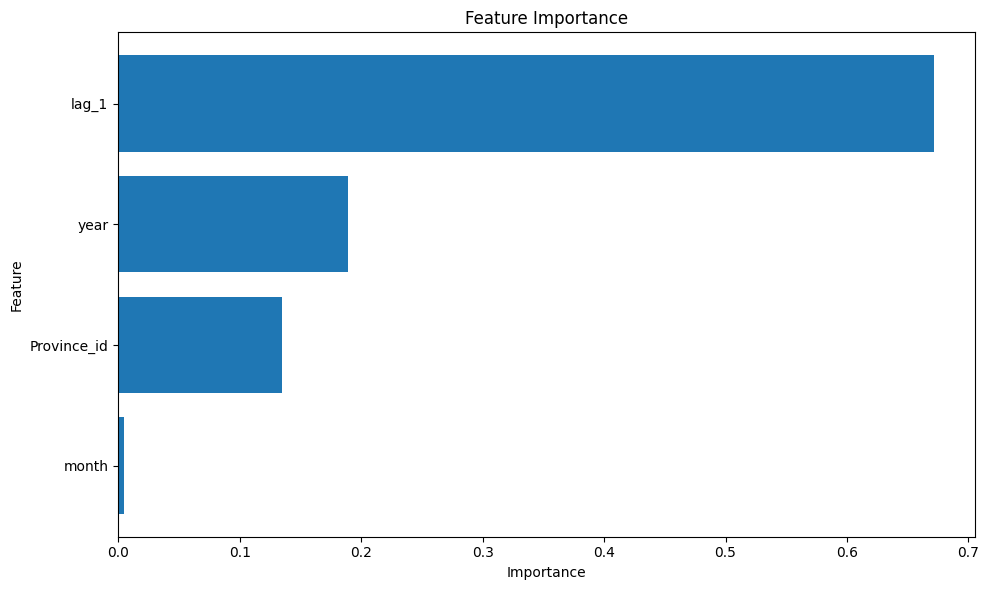

In [43]:
# Feature Importance
if hasattr(model, 'feature_importances_'):
    importances = model.feature_importances_
    feature_importance_df = pd.DataFrame({'feature': FEATURE_COLS, 'importance': importances})
    feature_importance_df = feature_importance_df.sort_values('importance', ascending=False)

    print("\n=== Feature Importance ===")
    print(feature_importance_df)

    # Plot feature importance
    plt.figure(figsize=(10, 6))
    plt.barh(feature_importance_df['feature'], feature_importance_df['importance'])
    plt.xlabel("Importance")
    plt.ylabel("Feature")
    plt.title("Feature Importance")
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()
else:
    print("Model has not been fitted yet. Please run the training cell first.")

# Knowledge Presentation



=== Random Forest Regression ===
Train Data : 90.0%
RMSE : 114.44
MAPE : 0.30%


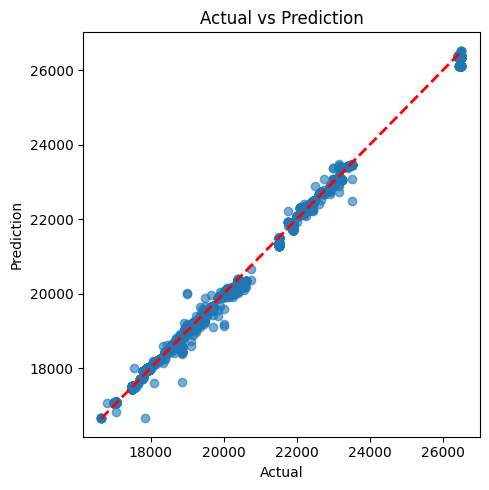

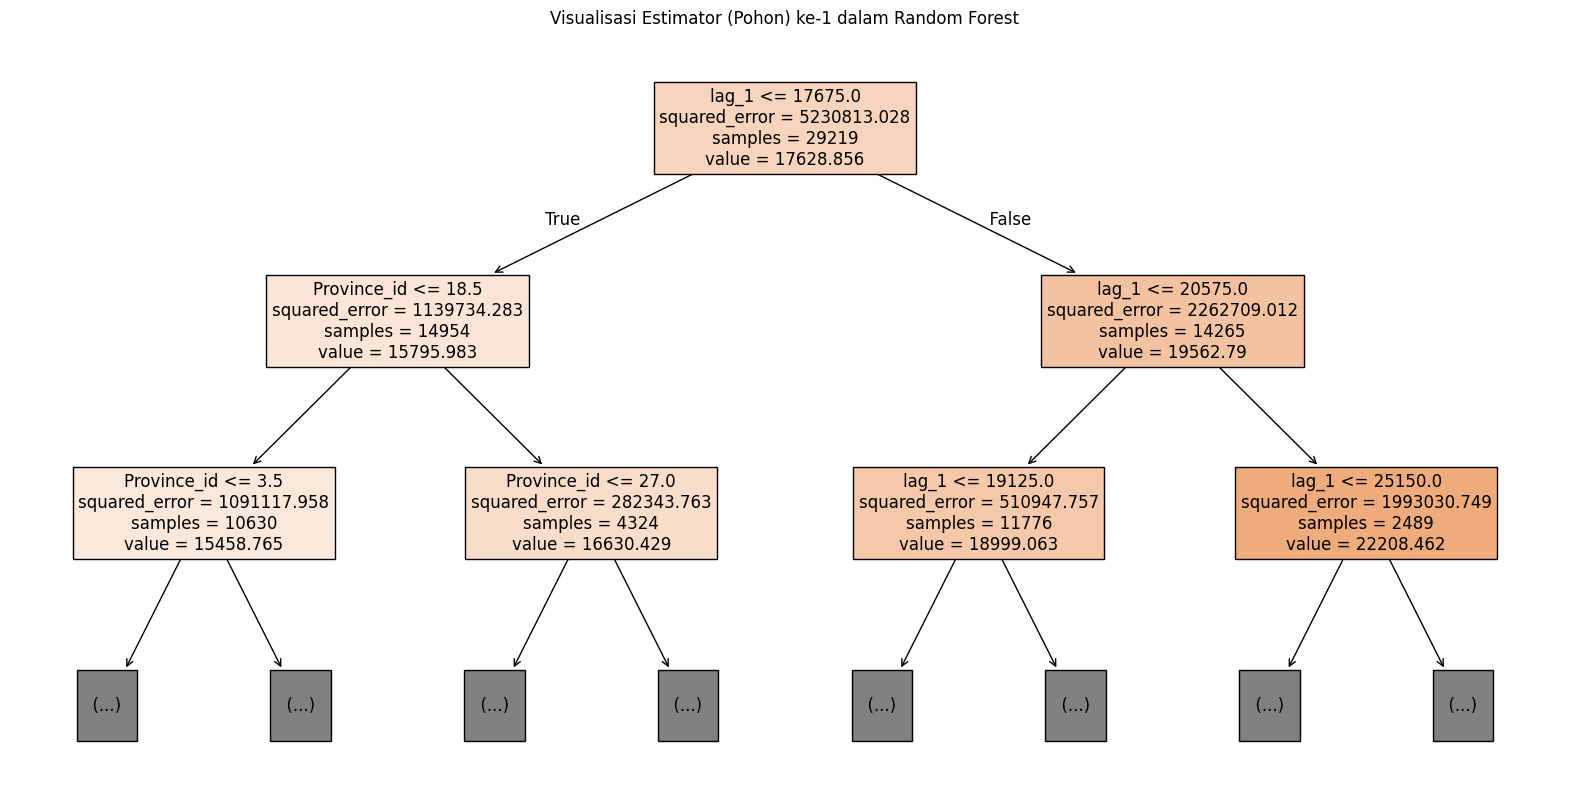

In [44]:
print("\n")
print("=== Random Forest Regression ===")
print(f"Train Data : {train_size*100}%")
print(f"RMSE : {rmse:,.2f}")
print(f"MAPE : {mape:.2f}%")

# Save prediction results for analysis
mined_df = pd.DataFrame(
    {
        "Date": df_mining.iloc[split_index:]["Date"].values,
        "Province": df_mining.iloc[split_index:]["Province"].values,
        "Actual": y_test.values,
        "Prediction": y_pred,
    }
)

# Export dataframe
mined_df.to_excel(mined_dataset_path, index=False)

# Show scatter plot between actual data vs prediction
plt.figure(figsize=(5, 5))
plt.scatter(mined_df["Actual"], mined_df["Prediction"], alpha=0.6)
max_val = max(mined_df["Actual"].max(), mined_df["Prediction"].max())
min_val = min(mined_df["Actual"].min(), mined_df["Prediction"].min())
plt.plot([min_val, max_val], [min_val, max_val], "r--", linewidth=2)

plt.title("Actual vs Prediction")
plt.xlabel("Actual")
plt.ylabel("Prediction")
plt.tight_layout()
plt.show()

# Show tree visualization
n_trees_to_view = 1

for i in range(n_trees_to_view):
    plt.figure(figsize=(20, 10))
    tree.plot_tree(model.estimators_[i], 
                   feature_names=X.columns, 
                   filled=True, 
                   max_depth=2,
                   fontsize=12)
    plt.title(f"Visualisasi Estimator (Pohon) ke-{i+1} dalam Random Forest")
    plt.show()

## Deep Dive

In [45]:
print("="*60)
print("PROSES BOOTSTRAPPING PADA POHON PERTAMA")
print("="*60)

# Ambil pohon pertama (index 0) dari model yang sudah dilatih
pohon_pertama = model.estimators_[0]

# Dapatkan index baris data hasil bootstrapping
n_samples = X_train.shape[0]
bootstrap_indices = _generate_sample_indices(pohon_pertama.random_state, n_samples, n_samples)

print(f"Total data training asli : {n_samples} baris")
print(f"Total data di bootstrap  : {len(bootstrap_indices)} baris (ukuran sama, tapi ada duplikasi acak)\n")

print("="*60)
print("FITUR YANG DIPILIH OLEH POHON PERTAMA")
print("="*60)

# Atribut tree_.feature menyimpan index fitur yang digunakan untuk splitting
# Nilai -2 (atau kurang dari 0) menandakan node tersebut adalah "daun" (leaf/keputusan akhir), bukan fitur
fitur_terpakai_idx = set([f for f in pohon_pertama.tree_.feature if f >= 0])
fitur_terpakai_nama = [X_train.columns[i] for i in fitur_terpakai_idx]

print(f"Dari total {len(X_train.columns)} fitur yang tersedia, pohon pertama menggunakan fitur berikut:")
for fitur in fitur_terpakai_nama:
    print(f"- {fitur}")
print("\n")

print("="*60)
print("PENCARIAN DATA BOOTSTRAP YANG RELEVAN (UNTUK TABEL LAPORAN)")
print("="*60)

# Ambil 1 baris data baru untuk diuji
sampel_uji = X_test.iloc[[0]]
nilai_aktual = y_test.iloc[0]

print(f"Nilai aktual yang diuji: Rp {nilai_aktual:,.0f}\n")

# Buat DataFrame sementara untuk data hasil bootstrap
df_bootstrap = X_train.iloc[bootstrap_indices].copy()
df_bootstrap['Harga_Actual_y'] = y_train.iloc[bootstrap_indices].values

# --- KUNCI VARIASI: Gunakan Rentang Margin ---
# Atur margin ± Rp 1.500 (Anda bisa mengubah angka ini jika ingin rentang lebih lebar/sempit)
margin = 1500
batas_bawah = nilai_aktual - margin
batas_atas = nilai_aktual + margin

print(f"Memfilter data dalam rentang: Rp {batas_bawah:,.0f} s.d Rp {batas_atas:,.0f}")

# Filter data agar hanya mengambil yang berada dalam rentang margin
df_range = df_bootstrap[(df_bootstrap['Harga_Actual_y'] >= batas_bawah) & 
                        (df_bootstrap['Harga_Actual_y'] <= batas_atas)]

# Hapus duplikasi agar tidak ada harga yang kembar
# LALU urutkan berdasarkan harga, BUKAN berdasarkan selisih.
df_variasi = df_range.drop_duplicates(subset=['Harga_Actual_y']).sort_values('Harga_Actual_y')

print(f"Ditemukan {len(df_variasi)} variasi harga yang unik dalam rentang tersebut.\n")

# --- GABUNGKAN 10 DATA MENJADI 1 TABEL UTUH ---
# Ambil 5 harga terendah dan 5 harga tertinggi, lalu gabungkan
df_manual = pd.concat([df_variasi.head(5), df_variasi.tail(5)]).drop_duplicates()

# Opsional: Acak sedikit urutannya agar terlihat seperti sampel natural (seperti di Tabel 18 PDF)
df_manual = df_manual.sample(frac=1, random_state=42).reset_index(drop=True)
# Jika ingin nomor indeks mulai dari 1 seperti di laporan:
df_manual.index = np.arange(1, len(df_manual) + 1)

print(f"Menampilkan 10 Data Sampel Acak (Salin tabel ini ke laporan Anda):")
display(df_manual)

PROSES BOOTSTRAPPING PADA POHON PERTAMA
Total data training asli : 46181 baris
Total data di bootstrap  : 46181 baris (ukuran sama, tapi ada duplikasi acak)

FITUR YANG DIPILIH OLEH POHON PERTAMA
Dari total 4 fitur yang tersedia, pohon pertama menggunakan fitur berikut:
- Province_id
- lag_1
- month
- year


PENCARIAN DATA BOOTSTRAP YANG RELEVAN (UNTUK TABEL LAPORAN)
Nilai aktual yang diuji: Rp 18,750

Memfilter data dalam rentang: Rp 17,250 s.d Rp 20,250
Ditemukan 61 variasi harga yang unik dalam rentang tersebut.

Menampilkan 10 Data Sampel Acak (Salin tabel ini ke laporan Anda):


,Province_id,lag_1,month,year,Harga_Actual_y
1,21,19750.0,9,2024,20200
2,5,17300.0,1,2024,17300
3,18,20050.0,2,2025,20050
4,8,17250.0,3,2024,17250
5,29,20150.0,2,2024,20150
6,4,17350.0,2,2024,17350
7,33,20250.0,12,2023,20250
8,29,17450.0,4,2023,17450
9,8,17400.0,3,2024,17400
10,21,20100.0,2,2025,20100


In [46]:
print("\n" + "="*60)
print("PERHITUNGAN MANUAL TITIK SPLIT TERPILIH (ROOT NODE)")
print("="*60)

# 1. Ekstrak Aturan Root (Akar) dari Pohon Pertama
pohon_pertama = model.estimators_[0]
root_feature_idx = pohon_pertama.tree_.feature[0]
root_threshold = pohon_pertama.tree_.threshold[0]
root_feature_name = X_train.columns[root_feature_idx]

# 2. Siapkan SELURUH data latih dari hasil bootstrap
X_boot = X_train.iloc[bootstrap_indices].copy()
y_boot = y_train.iloc[bootstrap_indices].values

df_full = X_boot.copy()
df_full['Harga_Actual'] = y_boot
N_total = len(df_full)

fitur = root_feature_name
s = root_threshold

print(f"Menggunakan SELURUH data latih (bootstrap) sebanyak {N_total} baris.")
print(f"Fitur split terbaik yang dipilih program : '{fitur}'")

# 3. Urutkan data berdasarkan fitur
df_sorted = df_full.sort_values(fitur).reset_index(drop=True)

# Cari tahu asal-usul nilai s (rata-rata 2 nilai yang bersebelahan)
nilai_fitur_unik = np.unique(df_sorted[fitur].values)
idx_kiri = np.searchsorted(nilai_fitur_unik, s, side='right') - 1
idx_kanan = idx_kiri + 1

if idx_kiri >= 0 and idx_kanan < len(nilai_fitur_unik):
    val_kiri = nilai_fitur_unik[idx_kiri]
    val_kanan = nilai_fitur_unik[idx_kanan]
    print(f"Ambang batas (s) terpilih                : {s:.2f}")
    print(f"Asal-usul perhitungan nilai s            : ({val_kiri} + {val_kanan}) / 2 = {s:.2f}\n")
else:
    print(f"Ambang batas (s) terpilih                : {s:.2f}\n")

# --- FUNGSI FORMATTING "..." (DIPERBARUI) ---
def format_deret(arr, is_mse=False, mean_val=0):
    if len(arr) == 0:
        return "0"
        
    # KUNCI PERBAIKAN: Urutkan array berdasarkan nilai harga (kecil ke besar)
    # agar harga ekstrem (seperti 20.000) selalu terlihat di ekor deretan.
    arr_sorted = np.sort(arr)
    
    if len(arr_sorted) <= 5:
        if is_mse:
            return " + ".join([f"({x} - {mean_val:.2f})^2" for x in arr_sorted])
        else:
            return " + ".join([str(x) for x in arr_sorted])
    else:
        # Tampilkan 2 di awal (terendah) dan 2 di akhir (tertinggi), pisahkan dengan "..."
        if is_mse:
            return f"({arr_sorted[0]} - {mean_val:.2f})^2 + ({arr_sorted[1]} - {mean_val:.2f})^2 + ... + ({arr_sorted[-2]} - {mean_val:.2f})^2 + ({arr_sorted[-1]} - {mean_val:.2f})^2"
        else:
            return f"{arr_sorted[0]} + {arr_sorted[1]} + ... + {arr_sorted[-2]} + {arr_sorted[-1]}"

# 4. Eksekusi Perhitungan Manual HANYA untuk titik split terpilih
print(f"Uji Split Terpilih ({fitur} <= {s:.2f})")

# --- KELOMPOK KIRI ---
kiri = df_sorted[df_sorted[fitur] <= s]
n_L = len(kiri)
y_L = kiri['Harga_Actual'].values
mean_L = np.mean(y_L) if n_L > 0 else 0
mse_L = np.mean((y_L - mean_L)**2) if n_L > 0 else 0

str_y_L = format_deret(y_L)
str_mse_L = format_deret(y_L, is_mse=True, mean_val=mean_L)

# --- KELOMPOK KANAN ---
kanan = df_sorted[df_sorted[fitur] > s]
n_R = len(kanan)
y_R = kanan['Harga_Actual'].values
mean_R = np.mean(y_R) if n_R > 0 else 0
mse_R = np.mean((y_R - mean_R)**2) if n_R > 0 else 0

str_y_R = format_deret(y_R)
str_mse_R = format_deret(y_R, is_mse=True, mean_val=mean_R)

# --- MSE GABUNGAN ---
mse_split = (n_L / N_total) * mse_L + (n_R / N_total) * mse_R

# Format cetak mirip dengan laporan PDF
print(f"  a) Split kiri")
print(f"     n_L = {n_L}")
print(f"     y_L_bar = ({str_y_L}) / {n_L} = {mean_L:.2f}")
print(f"     MSE_L = 1/{n_L} * [{str_mse_L}] = {mse_L:.2f}")

print(f"  b) Split kanan")
print(f"     n_R = {n_R}")
print(f"     y_R_bar = ({str_y_R}) / {n_R} = {mean_R:.2f}")
print(f"     MSE_R = 1/{n_R} * [{str_mse_R}] = {mse_R:.2f}")

print(f"  c) Hitung nilai split gabungan")
print(f"     MSE_split = {n_L}/{N_total}({mse_L:.2f}) + {n_R}/{N_total}({mse_R:.2f}) = {mse_split:.2f}\n")

print("-" * 60)
print(f"Kesimpulan: Ini adalah evaluasi langsung untuk split terbaik yang membentuk Node Akar (Root Node) pada Pohon Pertama.")


PERHITUNGAN MANUAL TITIK SPLIT TERPILIH (ROOT NODE)
Menggunakan SELURUH data latih (bootstrap) sebanyak 46181 baris.
Fitur split terbaik yang dipilih program : 'lag_1'
Ambang batas (s) terpilih                : 17675.00
Asal-usul perhitungan nilai s            : (17650.0 + 17700.0) / 2 = 17675.00

Uji Split Terpilih (lag_1 <= 17675.00)
  a) Split kiri
     n_L = 23710
     y_L_bar = (12200 + 12750 + ... + 19600 + 21000) / 23710 = 15795.98
     MSE_L = 1/23710 * [(12200 - 15795.98)^2 + (12750 - 15795.98)^2 + ... + (19600 - 15795.98)^2 + (21000 - 15795.98)^2] = 1139734.28
  b) Split kanan
     n_R = 22471
     y_R_bar = (17150 + 17400 + ... + 27000 + 27000) / 22471 = 19562.79
     MSE_R = 1/22471 * [(17150 - 19562.79)^2 + (17400 - 19562.79)^2 + ... + (27000 - 19562.79)^2 + (27000 - 19562.79)^2] = 2262709.01
  c) Hitung nilai split gabungan
     MSE_split = 23710/46181(1139734.28) + 22471/46181(2262709.01) = 1686157.38

------------------------------------------------------------
Kesimpu

In [47]:
print("\n" + "="*60)
print("SIMULASI PREDIKSI DATA UJI PADA POHON PERTAMA")
print("="*60)

# 1. Ambil pohon pertama dan struktur internalnya
pohon_pertama = model.estimators_[0]
tree_ = pohon_pertama.tree_
fitur_names = X_train.columns
nomor_index_df = 47249

if nomor_index_df not in X_test.index:
    print(f"Error: Nomor index {nomor_index_df} tidak ditemukan di X_test. Pastikan nomornya benar.")
else:
    # 2. Ambil 1 baris data uji
    sampel_uji = X_test.loc[[nomor_index_df]]
    nilai_aktual = y_test.loc[nomor_index_df]

    print("Data Uji yang akan diprediksi:")
    display(sampel_uji)
    print(f"Harga Aktual (Target) : Rp {nilai_aktual:,.0f}\n")

    print("--- TRACING KEPUTUSAN POHON (DECISION PATH) ---")
    node_saat_ini = 0
    langkah = 1
    sejarah_langkah = [] # List untuk menyimpan riwayat perjalanan node

    # 3. Looping selama node saat ini BUKAN leaf node
    while tree_.children_left[node_saat_ini] != -1: 
        fitur_idx = tree_.feature[node_saat_ini]
        nama_fitur = fitur_names[fitur_idx]
        threshold = tree_.threshold[node_saat_ini]
        nilai_sampel = sampel_uji[nama_fitur].values[0]
        
        # Evaluasi kondisi
        if nilai_sampel <= threshold:
            keputusan = f"{nilai_sampel:.2f} <= {threshold:.2f} -> Jatuh ke cabang KIRI"
            next_node = tree_.children_left[node_saat_ini]
        else:
            keputusan = f"{nilai_sampel:.2f} > {threshold:.2f} -> Jatuh ke cabang KANAN"
            next_node = tree_.children_right[node_saat_ini]
            
        # Simpan data langkah ini ke dalam riwayat
        sejarah_langkah.append({
            'langkah': langkah,
            'node': node_saat_ini,
            'nama_fitur': nama_fitur,
            'threshold': threshold,
            'nilai_sampel': nilai_sampel,
            'keputusan': keputusan
        })
        
        node_saat_ini = next_node
        langkah += 1

    # --- MENAMPILKAN HASIL TRACING YANG DISIMPAN ---
    
    # Tampilkan Tahap Awal (Langkah 1)
    if len(sejarah_langkah) > 0:
        awal = sejarah_langkah[0]
        print(f"TAHAP AWAL (Langkah {awal['langkah']} | Node {awal['node']} - Root Node):")
        print(f"  - Aturan Split          : {awal['nama_fitur']} <= {awal['threshold']:.2f}")
        print(f"  - Input data uji        : {awal['nama_fitur']} = {awal['nilai_sampel']:.2f}")
        print(f"  - Keputusan             : {awal['keputusan']}\n")

    # Tampilkan pembatas jika ada lebih dari 2 langkah (ada node perantara yang disembunyikan)
    if len(sejarah_langkah) > 2:
        print("... [Proses pengecekan node perantara disembunyikan] ...\n")
        
    # Tampilkan Tahap Sebelum Akhir (Langkah N-1)
    # Berlaku jika pohon memiliki lebih dari 1 langkah (Root Node tidak langsung menunjuk ke Leaf Node)
    if len(sejarah_langkah) > 1:
        sebelum_akhir = sejarah_langkah[-1]
        print(f"TAHAP SEBELUM AKHIR (Langkah {sebelum_akhir['langkah']} | Node {sebelum_akhir['node']}):")
        print(f"  - Aturan Split          : {sebelum_akhir['nama_fitur']} <= {sebelum_akhir['threshold']:.2f}")
        print(f"  - Input data uji        : {sebelum_akhir['nama_fitur']} = {sebelum_akhir['nilai_sampel']:.2f}")
        print(f"  - Keputusan             : {sebelum_akhir['keputusan']}\n")

    # 4. Tahap Akhir: Mencapai Leaf Node
    nilai_prediksi = tree_.value[node_saat_ini][0][0]
    jumlah_sampel_daun = tree_.n_node_samples[node_saat_ini]

    print(f"TAHAP AKHIR (Langkah {langkah} | Node {node_saat_ini} - Leaf Node):")
    print(f"  - Status Node           : Simpul akhir (mencapai ujung cabang)")
    print(f"  - Jumlah Sampel Latih   : {jumlah_sampel_daun} sampel berada di daun ini")
    print(f"  - Dasar Prediksi        : Rata-rata harga dari {jumlah_sampel_daun} sampel tersebut")
    print(f"  - Keputusan (y_hat)     : Rp {nilai_prediksi:,.2f}\n")

    print("="*60)
    print(f"KESIMPULAN: Prediksi T1 = Rp {nilai_prediksi:,.2f} | Harga Aktual = Rp {nilai_aktual:,.0f}")
    print("="*60)


SIMULASI PREDIKSI DATA UJI PADA POHON PERTAMA
Data Uji yang akan diprediksi:


,Province_id,lag_1,month,year
47249,30,22350.0,11,2025


Harga Aktual (Target) : Rp 22,350

--- TRACING KEPUTUSAN POHON (DECISION PATH) ---
TAHAP AWAL (Langkah 1 | Node 0 - Root Node):
  - Aturan Split          : lag_1 <= 17675.00
  - Input data uji        : lag_1 = 22350.00
  - Keputusan             : 22350.00 > 17675.00 -> Jatuh ke cabang KANAN

... [Proses pengecekan node perantara disembunyikan] ...

TAHAP SEBELUM AKHIR (Langkah 12 | Node 2257):
  - Aturan Split          : month <= 9.50
  - Input data uji        : month = 11.00
  - Keputusan             : 11.00 > 9.50 -> Jatuh ke cabang KANAN

TAHAP AKHIR (Langkah 13 | Node 2259 - Leaf Node):
  - Status Node           : Simpul akhir (mencapai ujung cabang)
  - Jumlah Sampel Latih   : 21 sampel berada di daun ini
  - Dasar Prediksi        : Rata-rata harga dari 21 sampel tersebut
  - Keputusan (y_hat)     : Rp 22,343.55

KESIMPULAN: Prediksi T1 = Rp 22,343.55 | Harga Aktual = Rp 22,350


In [48]:
# =====================================================================
# TAMBAHAN: MELIHAT DATA LATIH (SAMPEL) YANG BERADA DI DALAM LEAF NODE
# =====================================================================
print("\n" + "="*60)
print(f"MENGGALI ISI LEAF NODE {node_saat_ini}")
print("="*60)

# 1. Masukkan seluruh data latih ke dalam pohon ini untuk melihat mereka jatuh ke node mana
node_tujuan_semua_data_latih = pohon_pertama.apply(X_train)

# 2. Saring hanya data latih yang jatuh tepat di daun yang sama (node_saat_ini)
# Kita ambil X_train dan y_train yang sesuai
sampel_daun_X = X_train[node_tujuan_semua_data_latih == node_saat_ini]
sampel_daun_y = y_train[node_tujuan_semua_data_latih == node_saat_ini]

jumlah_asli = len(sampel_daun_X)
print(f"Ditemukan {jumlah_asli} baris data latih di dalam daun ini.")
print("Berikut adalah 5 data teratas dan terbawah yang membentuk nilai prediksi:\n")

# 3. Tampilkan 5 Data Teratas
print("--- 5 DATA TERATAS DI DALAM DAUN ---")
display(sampel_daun_X.head(5))
print("Target Aktual (y_train) 5 teratas:")
display(sampel_daun_y.head(5))

print("\n" + "-"*60 + "\n")

# 4. Tampilkan 5 Data Terbawah
print("--- 5 DATA TERBAWAH DI DALAM DAUN ---")
display(sampel_daun_X.tail(5))
print("Target Aktual (y_train) 5 terbawah:")
display(sampel_daun_y.tail(5))

# 5. Pembuktian Rata-rata
rata_rata_manual = sampel_daun_y.mean()
# Catatan: Jika nilai y_train adalah Series berdimensi 1, kita bisa langsung .mean()
# Jika outputnya DataFrame, pastikan mengambil kolom targetnya.
print("\n" + "="*60)
print(f"PEMBUKTIAN PREDIKSI:")
print(f"Rata-rata target (y_train) dari data di atas secara manual = Rp {rata_rata_manual:,.2f}")
print(f"Nilai prediksi asli dari Pohon (y_hat)                       = Rp {nilai_prediksi:,.2f}")
print("="*60)


MENGGALI ISI LEAF NODE 2259
Ditemukan 31 baris data latih di dalam daun ini.
Berikut adalah 5 data teratas dan terbawah yang membentuk nilai prediksi:

--- 5 DATA TERATAS DI DALAM DAUN ---


/home/reyvn/Dev/Py/RFR_Sugar_Price/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(


,Province_id,lag_1,month,year
45335,30,22350.0,10,2025
45368,30,22350.0,10,2025
45401,30,22350.0,10,2025
45434,30,22350.0,10,2025
45467,30,22350.0,10,2025


Target Aktual (y_train) 5 teratas:


45335    22350
45368    22350
45401    22350
45434    22350
45467    22350
Name: Price, dtype: int64


------------------------------------------------------------

--- 5 DATA TERBAWAH DI DALAM DAUN ---


,Province_id,lag_1,month,year
46112,29,22250.0,10,2025
46127,30,22350.0,10,2025
46145,29,22250.0,10,2025
46160,30,22350.0,10,2025
46178,29,22250.0,10,2025


Target Aktual (y_train) 5 terbawah:


46112    22250
46127    22350
46145    22250
46160    22350
46178    22250
Name: Price, dtype: int64


PEMBUKTIAN PREDIKSI:
Rata-rata target (y_train) dari data di atas secara manual = Rp 22,333.87
Nilai prediksi asli dari Pohon (y_hat)                       = Rp 22,343.55


In [49]:
import pandas as pd
import numpy as np

print("\n" + "="*60)
print("PREDIKSI INDIVIDUAL DARI MASING-MASING POHON")
print("="*60)

prediksi_individual = []
nama_pohon = []
total_pohon = len(model.estimators_)

# 1. Looping ke setiap pohon untuk mengumpulkan prediksi
for i, tree_estimator in enumerate(model.estimators_):
    # Menggunakan sampel_uji.values untuk menghindari warning nama fitur
    pred_tree = tree_estimator.predict(sampel_uji.values)[0]
    
    prediksi_individual.append(pred_tree)
    nama_pohon.append(f"Pohon ke-{i:02d}")

# 2. Buat Pandas DataFrame dari data yang terkumpul
df_prediksi = pd.DataFrame({
    'Pohon': nama_pohon,
    'Prediksi Harga (Asli)': prediksi_individual
})

# 3. Buat kolom baru khusus untuk tampilan dengan format Rupiah
df_prediksi['Prediksi Harga (Rp)'] = df_prediksi['Prediksi Harga (Asli)'].apply(lambda x: f"Rp {x:,.2f}")

# 4. Tampilkan tabel (Hanya menampilkan kolom Pohon dan Format Rupiah)
# Jika jumlah pohon sangat banyak (misal 100), Pandas akan otomatis 
# menyingkat tampilannya (menampilkan 5 teratas dan 5 terbawah)
display(df_prediksi[['Pohon', 'Prediksi Harga (Rp)']])


# 5. Bandingkan rata-rata dari seluruh pohon dengan prediksi akhir model
rata_rata_manual = np.mean(prediksi_individual)
prediksi_akhir_rf = model.predict(sampel_uji)[0]

print("\n" + "="*60)
print("KESIMPULAN PREDIKSI (Manual vs Program)")
print("="*60)
print(f"Rata-rata prediksi dari {total_pohon} pohon   : Rp {rata_rata_manual:,.2f}")
print(f"Prediksi akhir dari model (rf.predict) : Rp {prediksi_akhir_rf:,.2f}")
print("="*60)


PREDIKSI INDIVIDUAL DARI MASING-MASING POHON


,Pohon,Prediksi Harga (Rp)
0,Pohon ke-00,"Rp 22,343.55"
1,Pohon ke-01,"Rp 22,340.62"
2,Pohon ke-02,"Rp 22,337.10"
3,Pohon ke-03,"Rp 22,350.00"
4,Pohon ke-04,"Rp 22,331.08"
5,Pohon ke-05,"Rp 22,336.36"
6,Pohon ke-06,"Rp 22,350.00"
7,Pohon ke-07,"Rp 22,350.00"
8,Pohon ke-08,"Rp 22,350.00"
9,Pohon ke-09,"Rp 22,350.00"



KESIMPULAN PREDIKSI (Manual vs Program)
Rata-rata prediksi dari 50 pohon   : Rp 22,351.23
Prediksi akhir dari model (rf.predict) : Rp 22,351.23


# Optional

## Generate Sugar Price History Plot

In [50]:
if generate_history_plot :
    df = df_merged.copy()

    # Specify where output will be stored
    combined_path = Path(f"../output/{sugar_type}/plots/sugar_price_history.png")
    province_dir = Path(f"../output/{sugar_type}/plots/province_price_history/")
    combined_path.parent.mkdir(parents=True, exist_ok=True)
    province_dir.mkdir(parents=True, exist_ok=True)

    # All provinces combined plot
    plt.figure(figsize=(12, 6))

    for prov, g in df.groupby("Province"):
        plt.plot(g["Date"], g["Price"], label=prov, linewidth=0.8, alpha=0.7)

    plt.title("Riwayat Harga Gula per Provinsi")
    plt.xlabel("Tanggal")
    plt.ylabel("Harga (Rp)")
    plt.legend(
        title="Provinsi", fontsize=6, ncol=2, bbox_to_anchor=(1.05, 1), loc="upper left"
    )
    plt.tight_layout()
    plt.savefig(combined_path)
    plt.close()

    # Each individual province plot
    for prov, g in df.groupby("Province"):
        plt.figure(figsize=(10, 5))
        plt.plot(g["Date"], g["Price"], linewidth=1.5)

        plt.title(f"Riwayat Harga Gula - {prov}")
        plt.xlabel("Tanggal")
        plt.ylabel("Harga (Rp)")
        plt.tight_layout()

        file_name = prov.replace(" ", "_").replace("/", "_") + ".png"
        plt.savefig(province_dir / file_name)
        plt.close()
else :
    print("Skip Generating Sugar Price History Plot")

Skip Generating Sugar Price History Plot


## Generate PACF Plot

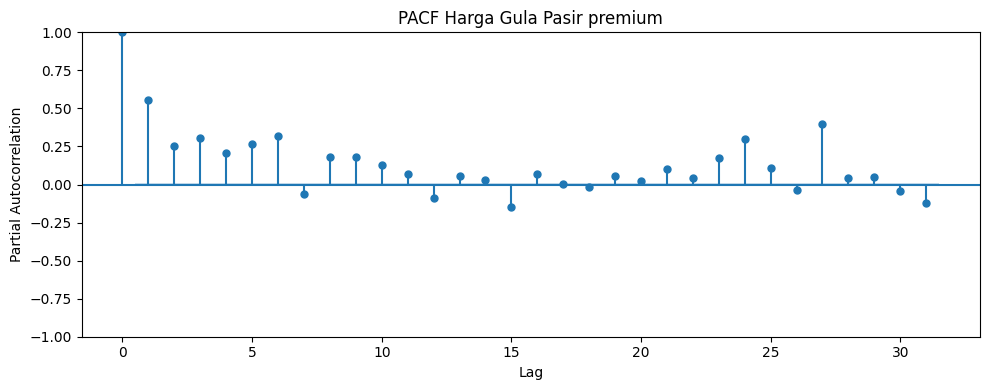

Lag yang signifikan menurut PACF: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31]


In [ ]:
if generate_pacf_plot :    
    df = df_transform.copy()
    y_full = df['Price'].astype(float)
    max_lag = 31

    # Plot PACF
    fig, ax = plt.subplots(figsize=(10, 4))
    plot_pacf(y_full, ax=ax, lags=max_lag, method="ywm")    # Method Yule-Walker Modified
    ax.set_title(f"PACF Harga Gula Pasir ({sugar_type})")
    ax.set_xlabel("Lag")
    ax.set_ylabel("Partial Autocorrelation")
    plt.tight_layout()
    plt.show()

    # Create PACF value as numeric + confidence interval
    pacf_vals, confint = pacf(
        y_full,
        nlags=max_lag,
        alpha=0.05, # 95% confidence interval
        method="ywm"
    )

    # Find significant lags
    significant_lags = [
        lag for lag in range(1, len(pacf_vals))
        if (confint[lag, 0] > 0) or (confint[lag, 1] < 0)
    ]

    print("Lag yang signifikan menurut PACF:", significant_lags)
else :
    print("Skip Generating PACF Plot")

## Compare Between Actual and Prediction Data

In [52]:
if compare_prediction :
    # Defined target range
    horizon = 180
    max_date = df_mining["Date"].max()
    range_target = max_date - pd.Timedelta(days=horizon)

    # Specify where outputs will be stored
    output_dir = Path(f"../output/{sugar_type}/xlsx")
    output_dir.mkdir(parents=True, exist_ok=True)
    output_path = output_dir / f"rfr_{horizon}days_comparison.xlsx"
    compare_plot_dir = Path(f"../output/{sugar_type}/plots/compare")
    compare_plot_dir.mkdir(parents=True, exist_ok=True)

    # Split train / test by year
    train_mask = df_mining["Date"] < range_target
    test_mask = df_mining["Date"] >= range_target

    # Check if data available for train and test
    if not train_mask.any():
        raise ValueError(f"Tidak ada data {horizon} hari untuk training.")
    if not test_mask.any():
        raise ValueError(f"Tidak ada data {horizon} hari untuk pengujian.")

    # Sort dataframe by Date
    df_train = df_mining[train_mask].sort_values(["Date", "Province"])
    df_test = df_mining[test_mask].sort_values(["Date", "Province"])

    # Create X, y train and test
    X_train = df_train[FEATURE_COLS]
    y_train = df_train[TARGET_COL]

    X_test = df_test[FEATURE_COLS]
    y_test = df_test[TARGET_COL]

    # Create Random Forest Regression Model
    model = RandomForestRegressor(**RFR_PARAMS)
    model.fit(X_train, y_train)

    # Predict
    y_pred = model.predict(X_test)

    # Evaluate Model
    rmse = root_mean_squared_error(y_test, y_pred)
    mape = mean_absolute_percentage_error(y_test, y_pred) * 100

    print("\n")
    print(f"=== Comparison for {horizon} days ===")
    print(f"Train data up to: {df_train['Date'].max().date()}")
    print(f"RMSE : {rmse:,.2f}")
    print(f"MAPE : {mape:.2f}%")

    # Export result
    result_df = pd.DataFrame(
        {
            "Date": df_test["Date"].values,
            "Province": df_test["Province"].values,
            "Actual": y_test.values,
            "Prediction": y_pred,
        }
    )

    result_df.to_excel(output_path, index=False)

    # Plot comparison result for each province
    for prov in sorted(result_df["Province"].unique()):
        sub = result_df[result_df["Province"] == prov][["Date", "Actual", "Prediction"]]

        fig, ax = plt.subplots(figsize=(12, 5))

        ax.plot(sub["Date"], sub["Actual"], label="Actual", linewidth=1.2)
        ax.plot(sub["Date"], sub["Prediction"], label="Prediction", linewidth=1.2)

        ax.set_title(f"Riwayat Harga Aktual vs Prediksi ({prov} - {horizon} hari)")
        ax.set_xlabel("Tanggal")
        ax.set_ylabel("Harga (Rp)")
        ax.legend()

        fig.tight_layout()
        safe_filename = prov.replace("/", "_").replace(" ", "_")
        fig.savefig(compare_plot_dir / f"{safe_filename}.png")

        plt.close(fig)
else :
    print("Skip Comparing Actual and Prediction Data")

Skip Comparing Actual and Prediction Data


## Forecast Future Data

In [53]:
if forecast_price :
    df = df_transform.copy()

    X_full = df[FEATURE_COLS]
    y_full = df[TARGET_COL]

    # Create Random Forest Regression Model
    model = RandomForestRegressor(**RFR_PARAMS)
    model.fit(X_full, y_full)

    # Specify how much data should be predicted
    horizon = 180

    forecast_results = []
    provinces = df["Province"].unique()

    # Specify where forecast output will be stored
    forecast_plot_dir = Path(f"../output/{sugar_type}/plots/forecast/")
    forecast_plot_dir.mkdir(parents=True, exist_ok=True)
    forecast_output_path = Path(f"../output/{sugar_type}/xlsx/rfr_forecast_future_data.xlsx")
    forecast_output_path.parent.mkdir(parents=True, exist_ok=True)

    # Forecast loop each province
    for prov in provinces:
        g = df[df["Province"] == prov].copy()
        g = g.sort_values("Date").reset_index(drop=True)

        last_date = g["Date"].max()
        last_rows = g.tail(30).copy()

        future_rows = []

        prov_id = g.iloc[-1]["Province_id"]

        # Forecast loop until specified horizon
        for i in range(1, horizon + 1):
            next_date = last_date + pd.Timedelta(days=i)
            
            # Time Based Features
            month = next_date.month
            year  = next_date.year

            # Lag Features
            lag_1  = last_rows.iloc[-1]["Price"]

            # Arrange future data features
            X_future = pd.DataFrame({
                "Province_id": [prov_id],
                "lag_1": [lag_1],
                "month": [month],
                "year": [year]
            })

            predicted_price = model.predict(X_future)[0]

            forecast_results.append({
                "Date": next_date,
                "Province": prov,
                "Prediction": round(predicted_price),
            })

            future_rows.append({
                "Date": next_date,
                "Price": predicted_price
            })

            # Update series
            last_rows = pd.concat([
                last_rows,
                pd.DataFrame([{
                    "Date": next_date,
                    "Price": predicted_price,
                    "Province": prov,
                    "Province_id": prov_id,
                }])
            ], ignore_index=True)

        # Plot
        history_cutoff = last_date - pd.DateOffset(months=6)
        g_recent = g[g["Date"] >= history_cutoff]

        future_df = pd.DataFrame(future_rows)

        plt.figure(figsize=(12, 5))
        plt.plot(g_recent["Date"], g_recent["Price"], label="Historical", linewidth=1.5)
        plt.plot(future_df["Date"], future_df["Price"], label=f"Forecast ({horizon} days)", linewidth=1.5)

        plt.title(f"Forecast Harga Gula - {prov}")
        plt.xlabel("Tanggal")
        plt.ylabel("Harga (Rp)")
        plt.legend()
        plt.tight_layout()

        file_name = prov.replace(" ", "_").replace("/", "_") + "_forecast.png"
        plt.savefig(forecast_plot_dir / file_name, dpi=150, bbox_inches="tight")
        plt.close()

    # Export Forecast Dataframe
    df_forecast = pd.DataFrame(forecast_results)
    df_forecast = df_forecast.sort_values(["Province", "Date"]).reset_index(drop=True)
    df_forecast.to_excel(forecast_output_path, index=False)
else :
    print("Skip Forecasting Sugar Prices")

Skip Forecasting Sugar Prices
